In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/sehaj1104/indian-road-accident-dataset-20222025/indian_roads_dataset.csv


# Blood on the Asphalt — Indian Road Accident Analysis 2022–2025

India has one of the highest road accident fatality rates in the world. Every day, hundreds of families are shattered by accidents that are — in most cases — entirely preventable.

This dataset contains 20,000 road accident records across major Indian cities from 2022 to 2025. It captures where accidents happen, when they happen, what causes them, how severe they are, and what environmental and traffic conditions were present at the time.

This notebook analyses all of it — in plain English, with visualisations that make the patterns impossible to ignore.

If this notebook helps you, please upvote.

---

## Table of Contents

| # | Section |
|---|---------|
| 1 | Setup and Data Loading |
| 2 | Data Quality and Feature Engineering |
| 3 | KPI Dashboard |
| 4 | Geographic Analysis |
| 5 | Temporal Analysis — When Do Accidents Happen? |
| 6 | Severity Analysis |
| 7 | Cause Analysis |
| 8 | Weather and Visibility Analysis |
| 9 | Road Type and Infrastructure Analysis |
| 10 | Festival and Peak Hour Analysis |
| 11 | Risk Score Analysis |
| 12 | Correlation and Statistical Analysis |
| 13 | Key Takeaways |

---
## Section 1 — Setup and Data Loading

In [2]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.io as pio
pio.renderers.default = 'kaggle'

plt.rcParams.update({
    'figure.facecolor': '#0d0d0d',
    'axes.facecolor':   '#141414',
    'axes.labelcolor':  'white',
    'xtick.color':      'white',
    'ytick.color':      'white',
    'text.color':       'white',
    'grid.color':       '#2a2a2a',
    'figure.dpi':       130
})

SEVERITY_COLORS = {
    'fatal': '#e74c3c',
    'major': '#e67e22',
    'minor': '#f1c40f'
}
CAUSE_COLORS = {
    'overspeeding':   '#e74c3c',
    'drunk driving':  '#8e44ad',
    'distraction':    '#e67e22',
    'weather':        '#2980b9',
    'poor road':      '#7f8c8d'
}
ROAD_COLORS = {
    'highway': '#e74c3c',
    'urban':   '#2980b9',
    'rural':   '#27ae60'
}
ACC_PALETTE = ['#e74c3c','#e67e22','#f1c40f','#2980b9',
               '#27ae60','#8e44ad','#16a085','#2c3e50']

print('Libraries loaded.')

Libraries loaded.


In [3]:

df = pd.read_csv('/kaggle/input/datasets/sehaj1104/indian-road-accident-dataset-20222025/indian_roads_dataset.csv')

print(f'Shape   : {df.shape[0]:,} rows x {df.shape[1]} columns')
print(f'Columns : {df.columns.tolist()}')
df.head(10)

Shape   : 20,000 rows x 24 columns
Columns : ['accident_id', 'city', 'state', 'latitude', 'longitude', 'date', 'time', 'hour', 'day_of_week', 'is_weekend', 'road_type', 'lanes', 'traffic_signal', 'weather', 'visibility', 'temperature', 'traffic_density', 'cause', 'accident_severity', 'vehicles_involved', 'casualties', 'is_peak_hour', 'festival', 'risk_score']


,accident_id,city,state,latitude,longitude,date,time,hour,day_of_week,is_weekend,...,visibility,temperature,traffic_density,cause,accident_severity,vehicles_involved,casualties,is_peak_hour,festival,risk_score
0,0,Pune,Maharashtra,18.680827,73.930388,2023-10-22,5:00,5,Sunday,1,...,low,32,high,weather,fatal,2,2,0,NaN,0.85
1,1,Mumbai,Maharashtra,18.817732,72.790846,2023-05-21,4:00,4,Sunday,1,...,high,34,low,weather,major,4,3,0,NaN,0.10
2,2,Mumbai,Maharashtra,19.096889,72.819424,2024-07-10,13:00,13,Wednesday,0,...,low,21,medium,weather,minor,1,1,0,NaN,0.45
3,3,Chandigarh,Punjab,30.787805,76.847507,2025-03-30,11:00,11,Sunday,1,...,low,30,high,distraction,minor,5,2,0,NaN,0.65
4,4,Chennai,Tamil Nadu,12.965155,80.283313,2024-01-25,16:00,16,Thursday,0,...,high,24,low,distraction,minor,2,1,0,NaN,0.10
5,5,Delhi,Delhi,28.799490,77.049666,2024-07-29,8:00,8,Monday,0,...,high,36,high,overspeeding,fatal,4,4,1,NaN,0.65
6,6,Bangalore,Karnataka,13.064327,77.530941,2025-03-24,6:00,6,Monday,0,...,high,33,high,drunk driving,minor,4,4,0,NaN,0.30
7,7,Chandigarh,Punjab,30.786617,76.733947,2023-05-07,14:00,14,Sunday,1,...,high,25,low,weather,major,3,0,0,NaN,0.10
8,8,Hyderabad,Telangana,17.422447,78.464881,2022-02-25,3:00,3,Friday,0,...,low,22,low,poor road,minor,1,0,0,NaN,0.45
9,9,Bangalore,Karnataka,12.939033,77.498966,2024-03-31,4:00,4,Sunday,1,...,high,23,low,weather,minor,1,0,0,NaN,0.10


---
## Section 2 — Data Quality and Feature Engineering

The dataset is remarkably clean — only the festival column has missing values (19,885 nulls) which is expected because most days are not festival days.

New features we engineer:
- **festival_flag** — binary: 1 if a festival was recorded, 0 otherwise
- **date parsed** — convert date string to datetime for time series analysis
- **month, year, quarter** — extracted from date
- **casualties_per_vehicle** — how many casualties per vehicle involved
- **severity_numeric** — ordinal encoding of severity for correlation analysis
- **hour_bin** — time of day category (Night / Early Morning / Morning / Afternoon / Evening)

In [4]:
# Exact column names
acc_id_col    = 'accident_id'
city_col      = 'city'
state_col     = 'state'
lat_col       = 'latitude'
lon_col       = 'longitude'
date_col      = 'date'
time_col      = 'time'
hour_col      = 'hour'
dow_col       = 'day_of_week'
weekend_col   = 'is_weekend'
road_col      = 'road_type'
lanes_col     = 'lanes'
signal_col    = 'traffic_signal'
weather_col   = 'weather'
vis_col       = 'visibility'
temp_col      = 'temperature'
density_col   = 'traffic_density'
cause_col     = 'cause'
severity_col  = 'accident_severity'
vehicles_col  = 'vehicles_involved'
casualties_col= 'casualties'
peak_col      = 'is_peak_hour'
festival_col  = 'festival'
risk_col      = 'risk_score'

print('Column mapping complete.')

Column mapping complete.


In [5]:
# Parse date
df[date_col] = pd.to_datetime(df[date_col], errors='coerce')
df['month']     = df[date_col].dt.month
df['month_name']= df[date_col].dt.strftime('%b')
df['year']      = df[date_col].dt.year
df['quarter']   = df[date_col].dt.quarter

# Festival flag
df['festival_flag'] = df[festival_col].notna().astype(int)
df['festival_label']= df[festival_col].fillna('No Festival')

# Casualties per vehicle
df['casualties_per_vehicle'] = (
    df[casualties_col] / df[vehicles_col].replace(0, np.nan)
).round(3)

# Severity numeric
severity_map = {'minor': 1, 'major': 2, 'fatal': 3}
df['severity_numeric'] = df[severity_col].map(severity_map)

# Hour bin
def hour_bin(h):
    if   0  <= h < 5:  return 'Night (0-4)'
    elif 5  <= h < 9:  return 'Early Morning (5-8)'
    elif 9  <= h < 12: return 'Morning (9-11)'
    elif 12 <= h < 17: return 'Afternoon (12-16)'
    elif 17 <= h < 21: return 'Evening (17-20)'
    else:              return 'Night (21-23)'

df['hour_bin'] = df[hour_col].apply(hour_bin)

# Day order for sorting
DAY_ORDER = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
MONTH_ORDER = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']

print(f'Feature engineering complete. Total features: {df.shape[1]}')
print(f'\nYear distribution:\n{df["year"].value_counts().sort_index().to_string()}')
print(f'\nSeverity distribution:\n{df[severity_col].value_counts().to_string()}')
print(f'\nFestival accidents: {df["festival_flag"].sum()} ({df["festival_flag"].mean()*100:.1f}%)')

Feature engineering complete. Total features: 33

Year distribution:
year
2022    6117
2023    6088
2024    6061
2025    1734

Severity distribution:
accident_severity
minor    11025
major     5988
fatal     2987

Festival accidents: 115 (0.6%)


---
## Section 3 — KPI Dashboard

The headline numbers that summarise 20,000 road accident records.

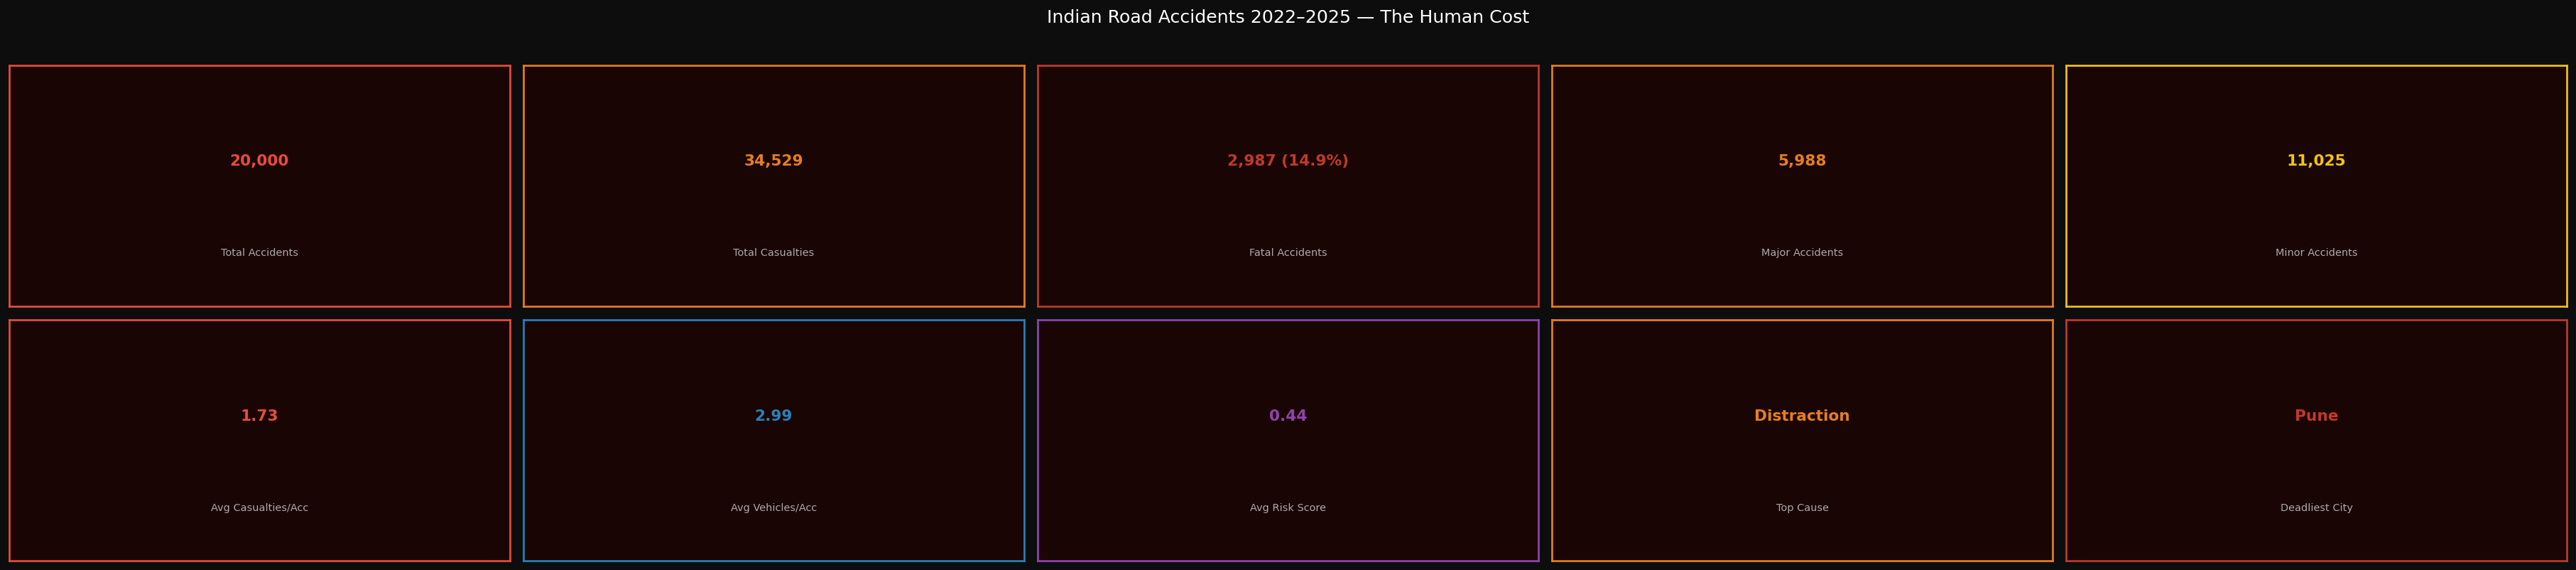

In [6]:
total_accidents  = len(df)
total_casualties = df[casualties_col].sum()
total_fatal      = (df[severity_col] == 'fatal').sum()
total_major      = (df[severity_col] == 'major').sum()
total_minor      = (df[severity_col] == 'minor').sum()
fatal_pct        = total_fatal / total_accidents * 100
avg_casualties   = df[casualties_col].mean()
avg_vehicles     = df[vehicles_col].mean()
avg_risk         = df[risk_col].mean()
top_cause        = df[cause_col].value_counts().idxmax()
deadliest_city   = df[df[severity_col]=='fatal'][city_col].value_counts().idxmax()
top_weather      = df[df[severity_col]=='fatal'][weather_col].value_counts().idxmax()

metrics = [
    ('Total Accidents',      f'{total_accidents:,}'),
    ('Total Casualties',     f'{total_casualties:,}'),
    ('Fatal Accidents',      f'{total_fatal:,} ({fatal_pct:.1f}%)'),
    ('Major Accidents',      f'{total_major:,}'),
    ('Minor Accidents',      f'{total_minor:,}'),
    ('Avg Casualties/Acc',   f'{avg_casualties:.2f}'),
    ('Avg Vehicles/Acc',     f'{avg_vehicles:.2f}'),
    ('Avg Risk Score',       f'{avg_risk:.2f}'),
    ('Top Cause',            top_cause.title()),
    ('Deadliest City',       deadliest_city),
]

fig, axes = plt.subplots(2, 5, figsize=(28, 6))
fig.patch.set_facecolor('#0d0d0d')
axes = axes.flatten()
colors = ['#e74c3c','#e67e22','#c0392b','#e67e22','#f1c40f',
          '#e74c3c','#2980b9','#8e44ad','#e67e22','#c0392b']

for ax, (label, value), color in zip(axes, metrics, colors):
    ax.set_facecolor('#1a0505')
    ax.text(0.5, 0.60, value, ha='center', va='center',
            fontsize=12, fontweight='bold', color=color,
            transform=ax.transAxes)
    ax.text(0.5, 0.22, label, ha='center', va='center',
            fontsize=8, color='#aaaaaa', transform=ax.transAxes)
    ax.set_xticks([]); ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_edgecolor(color); spine.set_linewidth(1.5)

plt.suptitle('Indian Road Accidents 2022–2025 — The Human Cost',
             fontsize=14, color='white', y=1.02)
plt.tight_layout()
plt.show()


## Section 4 — Geographic Analysis

Which cities and states record the most accidents? Where are the deadliest locations? We map every accident and compare cities across severity metrics.

In [7]:
# Accidents by city
city_summary = df.groupby(city_col).agg(
    total_accidents =(acc_id_col,    'count'),
    total_casualties=(casualties_col,'sum'),
    fatal_count     =(severity_col,  lambda x: (x=='fatal').sum()),
    avg_risk        =(risk_col,      'mean')
).reset_index().sort_values('total_accidents', ascending=False)

city_summary['fatality_rate'] = (
    city_summary['fatal_count'] / city_summary['total_accidents'] * 100
).round(2)

fig = make_subplots(rows=1, cols=2,
                    subplot_titles=['Total Accidents by City',
                                    'Total Casualties by City'])

fig.add_trace(go.Bar(
    x=city_summary['total_accidents'], y=city_summary[city_col],
    orientation='h', marker_color='#e74c3c',
    text=city_summary['total_accidents'], textposition='outside'
), row=1, col=1)

fig.add_trace(go.Bar(
    x=city_summary['total_casualties'], y=city_summary[city_col],
    orientation='h', marker_color='#e67e22',
    text=city_summary['total_casualties'], textposition='outside'
), row=1, col=2)

for i in [1, 2]:
    fig.update_yaxes(categoryorder='total ascending', row=1, col=i)

fig.update_layout(title='Which Cities Have the Most Accidents and Casualties?',
                  template='plotly_dark', height=480, showlegend=False)
fig.show()

In [8]:
# Fatality rate by city
fig = px.bar(
    city_summary.sort_values('fatality_rate', ascending=True),
    x='fatality_rate', y=city_col,
    orientation='h',
    color='fatality_rate', color_continuous_scale='Reds',
    title='Fatality Rate by City (% of Accidents that are Fatal)',
    text=city_summary.sort_values('fatality_rate')['fatality_rate'].round(1),
    labels={'fatality_rate': 'Fatality Rate (%)'}
)
fig.update_traces(texttemplate='%{text}%', textposition='outside')
fig.update_layout(template='plotly_dark', coloraxis_showscale=False)
fig.show()

In [9]:
# State comparison
state_summary = df.groupby(state_col).agg(
    total=(acc_id_col, 'count'),
    fatal=(severity_col, lambda x: (x=='fatal').sum()),
    casualties=(casualties_col, 'sum')
).reset_index()
state_summary['fatality_rate'] = (state_summary['fatal']/state_summary['total']*100).round(2)

display(state_summary.sort_values('total', ascending=False)
        .style.background_gradient(cmap='Reds', subset=['total','fatal','casualties'])
        .format({'fatality_rate': '{:.1f}%'}))

,state,total,fatal,casualties,fatality_rate
2,Maharashtra,5009,757,8716,15.1%
3,Punjab,2577,378,4377,14.7%
4,Tamil Nadu,2575,371,4567,14.4%
6,West Bengal,2559,377,4508,14.7%
1,Karnataka,2438,384,4128,15.8%
0,Delhi,2433,382,4175,15.7%
5,Telangana,2409,338,4058,14.0%


## Section 5 — Temporal Analysis — When Do Accidents Happen?

Road accidents are not random in time. They cluster around specific hours, days, and months. Understanding when accidents happen is the first step toward preventing them.

In [10]:
# Accidents by hour
hour_data = df.groupby(hour_col).agg(
    count   =(acc_id_col,    'count'),
    fatal   =(severity_col,  lambda x: (x=='fatal').sum()),
    casualties=(casualties_col,'mean')
).reset_index()

fig = make_subplots(rows=2, cols=1,
                    subplot_titles=['Accidents by Hour of Day',
                                    'Fatal Accidents by Hour of Day'],
                    shared_xaxes=True)

fig.add_trace(go.Bar(
    x=hour_data[hour_col], y=hour_data['count'],
    marker_color='#e67e22', name='Total Accidents'
), row=1, col=1)

fig.add_trace(go.Bar(
    x=hour_data[hour_col], y=hour_data['fatal'],
    marker_color='#e74c3c', name='Fatal Accidents'
), row=2, col=1)

# Add peak hour shading
for row in [1, 2]:
    fig.add_vrect(x0=7.5, x1=9.5, fillcolor='yellow',
                  opacity=0.08, line_width=0, row=row, col=1)
    fig.add_vrect(x0=17.5, x1=19.5, fillcolor='yellow',
                  opacity=0.08, line_width=0, row=row, col=1)

fig.update_layout(title='When Do Accidents and Fatalities Peak?',
                  xaxis_title='Hour of Day',
                  template='plotly_dark', height=560, showlegend=True)
fig.show()

In [11]:
# Day of week analysis
dow_data = df.groupby(dow_col).agg(
    count=(acc_id_col,   'count'),
    fatal=(severity_col, lambda x: (x=='fatal').sum()),
    casualties=(casualties_col, 'sum')
).reindex(DAY_ORDER).reset_index()

fig = make_subplots(rows=1, cols=2,
                    subplot_titles=['Accidents by Day of Week',
                                    'Fatalities by Day of Week'])

fig.add_trace(go.Bar(
    x=dow_data[dow_col], y=dow_data['count'],
    marker_color=['#e74c3c' if d in ['Saturday','Sunday'] else '#2980b9'
                  for d in dow_data[dow_col]],
    text=dow_data['count'], textposition='outside'
), row=1, col=1)

fig.add_trace(go.Bar(
    x=dow_data[dow_col], y=dow_data['fatal'],
    marker_color=['#c0392b' if d in ['Saturday','Sunday'] else '#e67e22'
                  for d in dow_data[dow_col]],
    text=dow_data['fatal'], textposition='outside'
), row=1, col=2)

fig.update_layout(title='Weekends vs Weekdays — Do Accident Patterns Differ?',
                  template='plotly_dark', height=430, showlegend=False)
fig.show()

In [12]:
# Monthly trend
month_data = df.groupby(['year','month','month_name']).agg(
    count=(acc_id_col, 'count'),
    fatal=(severity_col, lambda x: (x=='fatal').sum())
).reset_index().sort_values(['year','month'])
month_data['period'] = month_data['month_name'] + ' ' + month_data['year'].astype(str)

fig = px.line(
    month_data, x='period', y='count',
    color='year', markers=True,
    title='Monthly Accident Trend by Year',
    labels={'count': 'Number of Accidents', 'period': 'Month'},
    color_discrete_sequence=ACC_PALETTE
)
fig.update_layout(template='plotly_dark', height=430, xaxis_tickangle=-45)
fig.show()

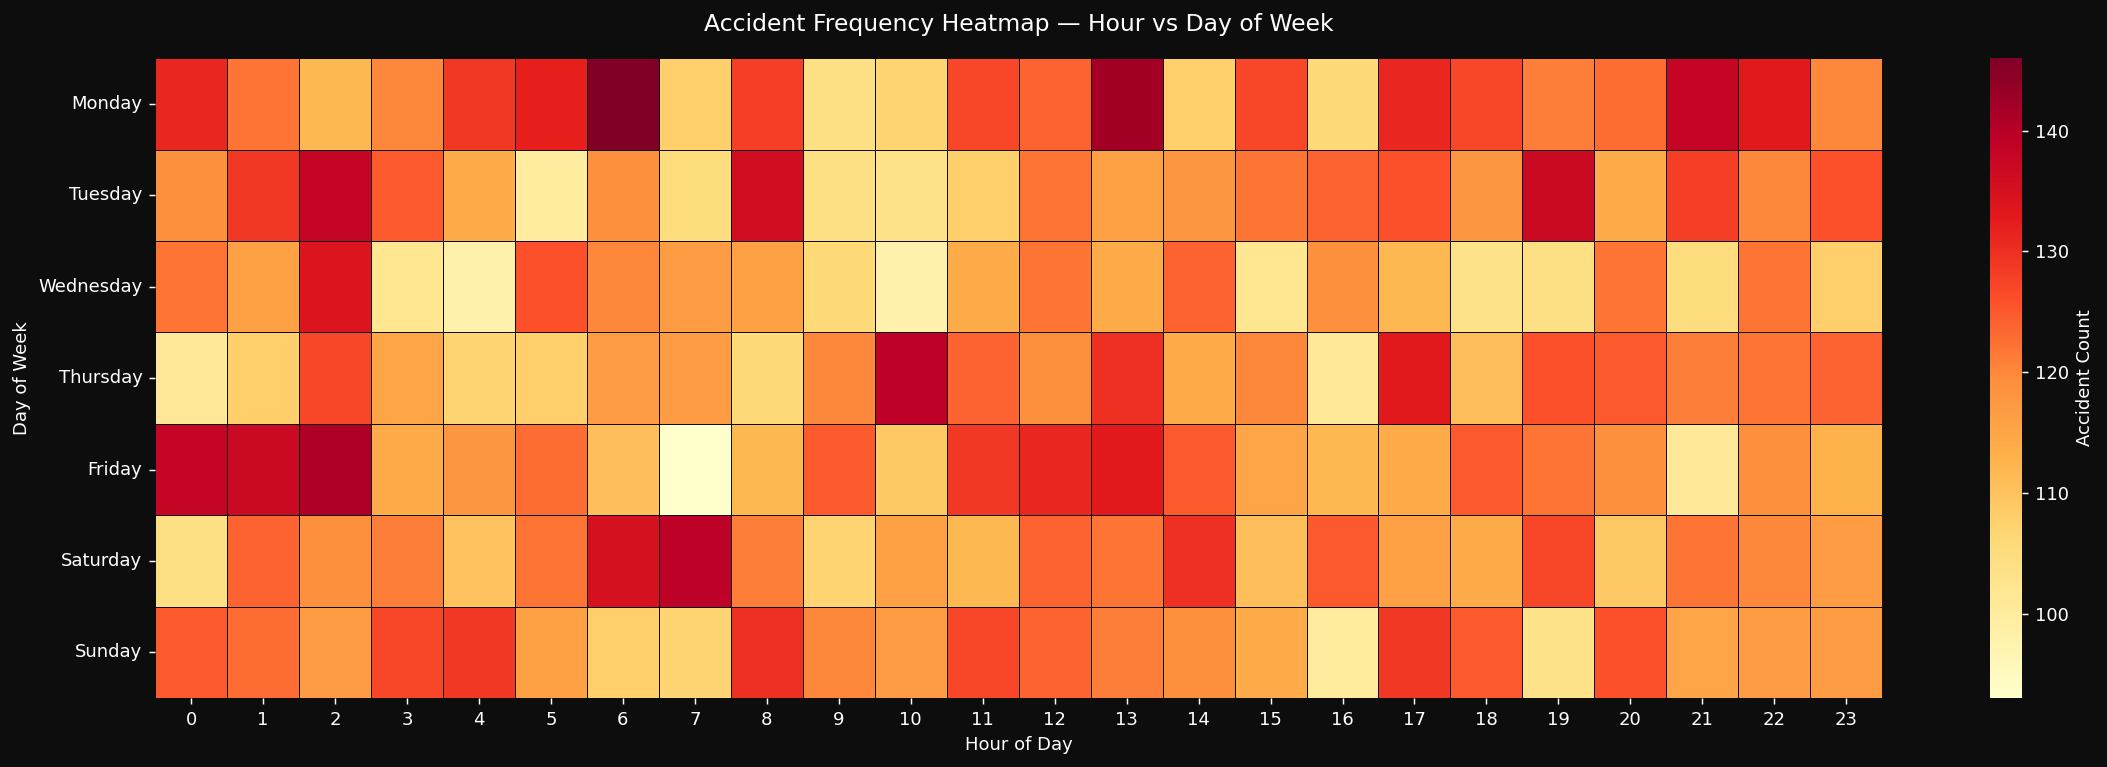

In [13]:
# Heatmap — hour vs day of week
heatmap_data = df.groupby([dow_col, hour_col])[acc_id_col].count().unstack(fill_value=0)
heatmap_data = heatmap_data.reindex(DAY_ORDER)

fig, ax = plt.subplots(figsize=(18, 6))
ax.set_facecolor('#141414')
sns.heatmap(heatmap_data, cmap='YlOrRd', ax=ax,
            linewidths=0.3, linecolor='#0d0d0d',
            annot=False, cbar_kws={'label': 'Accident Count'})
ax.set_title('Accident Frequency Heatmap — Hour vs Day of Week',
             fontsize=13, pad=15)
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Day of Week')
plt.tight_layout()
plt.show()

## Section 6 — Severity Analysis

Not all accidents are equal. Fatal accidents end lives. Major accidents cause serious injury. Minor accidents cause property damage and disruption. Understanding what drives severity is the most important question in road safety research.

In [14]:
# Severity distribution overall
sev_counts = df[severity_col].value_counts()

fig = make_subplots(rows=1, cols=2,
                    specs=[[{'type':'domain'},{'type':'xy'}]],
                    subplot_titles=['Severity Distribution',
                                    'Casualties by Severity'])

fig.add_trace(go.Pie(
    labels=sev_counts.index, values=sev_counts.values,
    hole=0.4,
    marker_colors=[SEVERITY_COLORS.get(s,'#95a5a6') for s in sev_counts.index]
), row=1, col=1)

sev_cas = df.groupby(severity_col)[casualties_col].mean().reset_index()
fig.add_trace(go.Bar(
    x=sev_cas[severity_col], y=sev_cas[casualties_col],
    marker_color=[SEVERITY_COLORS.get(s,'#95a5a6') for s in sev_cas[severity_col]],
    text=sev_cas[casualties_col].round(2), textposition='outside'
), row=1, col=2)

fig.update_layout(title='Accident Severity — Distribution and Average Casualties',
                  template='plotly_dark', height=430)
fig.show()

In [15]:
# Severity by road type, weather, time of day
fig = make_subplots(rows=1, cols=3,
                    subplot_titles=['Severity by Road Type',
                                    'Severity by Weather',
                                    'Severity by Hour Bin'])

for col_var, pos in [(road_col,1),(weather_col,2),('hour_bin',3)]:
    sev_cross = pd.crosstab(df[col_var], df[severity_col], normalize='index') * 100
    for sev in ['fatal','major','minor']:
        if sev in sev_cross.columns:
            fig.add_trace(go.Bar(
                x=sev_cross.index, y=sev_cross[sev],
                name=sev.title(),
                marker_color=SEVERITY_COLORS[sev],
                showlegend=(pos==1),
                text=sev_cross[sev].round(1),
                texttemplate='%{text}%', textposition='inside'
            ), row=1, col=pos)

fig.update_layout(title='What Conditions Make Accidents More Deadly?',
                  template='plotly_dark', height=480,
                  barmode='stack', xaxis_tickangle=-20)
fig.show()

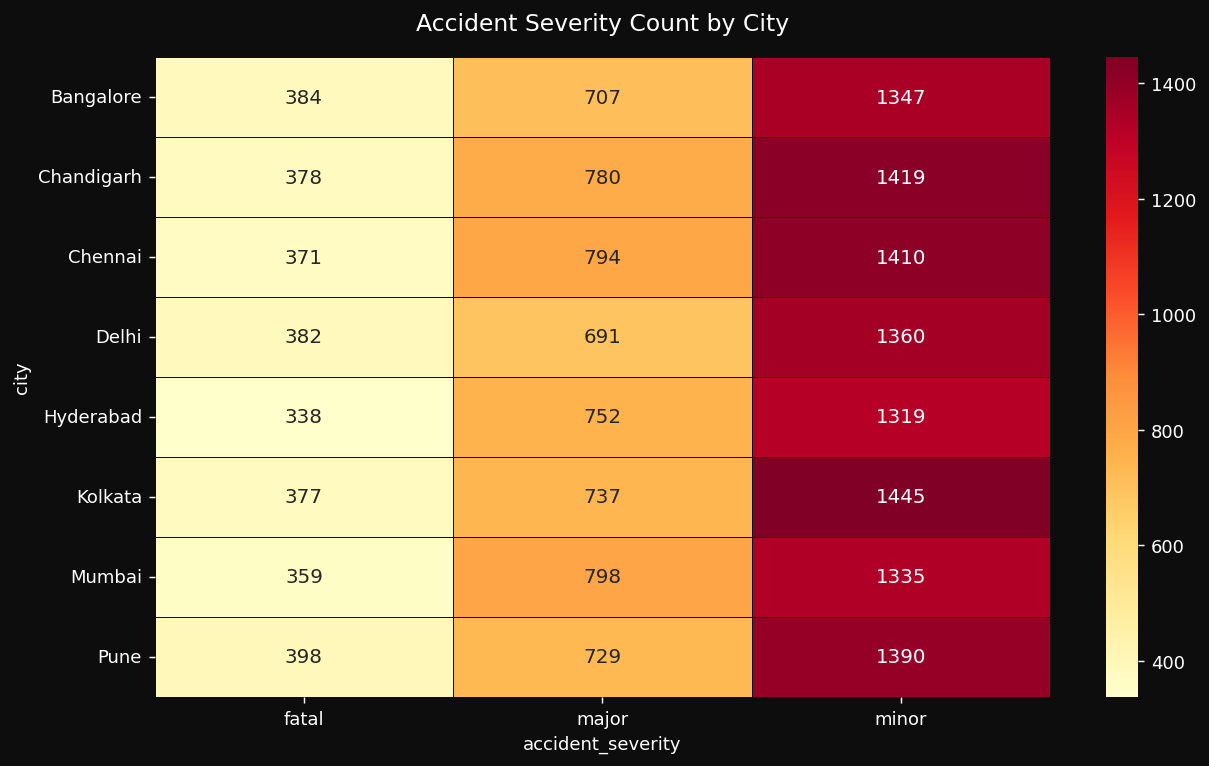

In [16]:
# Severity heatmap — city vs severity
sev_city = pd.crosstab(df[city_col], df[severity_col])

fig, ax = plt.subplots(figsize=(10, 6))
ax.set_facecolor('#141414')
sns.heatmap(sev_city, annot=True, fmt='d', cmap='YlOrRd',
            linewidths=0.5, linecolor='#0d0d0d', ax=ax,
            annot_kws={'size': 11})
ax.set_title('Accident Severity Count by City', fontsize=13, pad=15)
plt.tight_layout()
plt.show()

## Section 7 — Cause Analysis

Five causes are recorded: overspeeding, drunk driving, distraction, weather, and poor road conditions. Each has a different prevention strategy — and each affects different demographics and times differently.

In [17]:
# Cause distribution
cause_summary = df.groupby(cause_col).agg(
    count    =(acc_id_col,    'count'),
    fatal    =(severity_col,  lambda x: (x=='fatal').sum()),
    casualties=(casualties_col,'sum'),
    avg_risk =(risk_col,      'mean')
).reset_index().sort_values('count', ascending=False)
cause_summary['fatality_rate'] = (
    cause_summary['fatal'] / cause_summary['count'] * 100
).round(2)

fig = make_subplots(rows=1, cols=2,
                    specs=[[{'type':'domain'},{'type':'xy'}]],
                    subplot_titles=['Accident Share by Cause',
                                    'Fatality Rate by Cause (%)'])

fig.add_trace(go.Pie(
    labels=cause_summary[cause_col], values=cause_summary['count'],
    hole=0.4,
    marker_colors=[CAUSE_COLORS.get(c,'#95a5a6') for c in cause_summary[cause_col]]
), row=1, col=1)

fig.add_trace(go.Bar(
    x=cause_summary[cause_col], y=cause_summary['fatality_rate'],
    marker_color=[CAUSE_COLORS.get(c,'#95a5a6') for c in cause_summary[cause_col]],
    text=cause_summary['fatality_rate'].round(1),
    texttemplate='%{text}%', textposition='outside'
), row=1, col=2)

fig.update_layout(title='What Causes Road Accidents — and Which Causes Kill Most?',
                  template='plotly_dark', height=450)
fig.show()

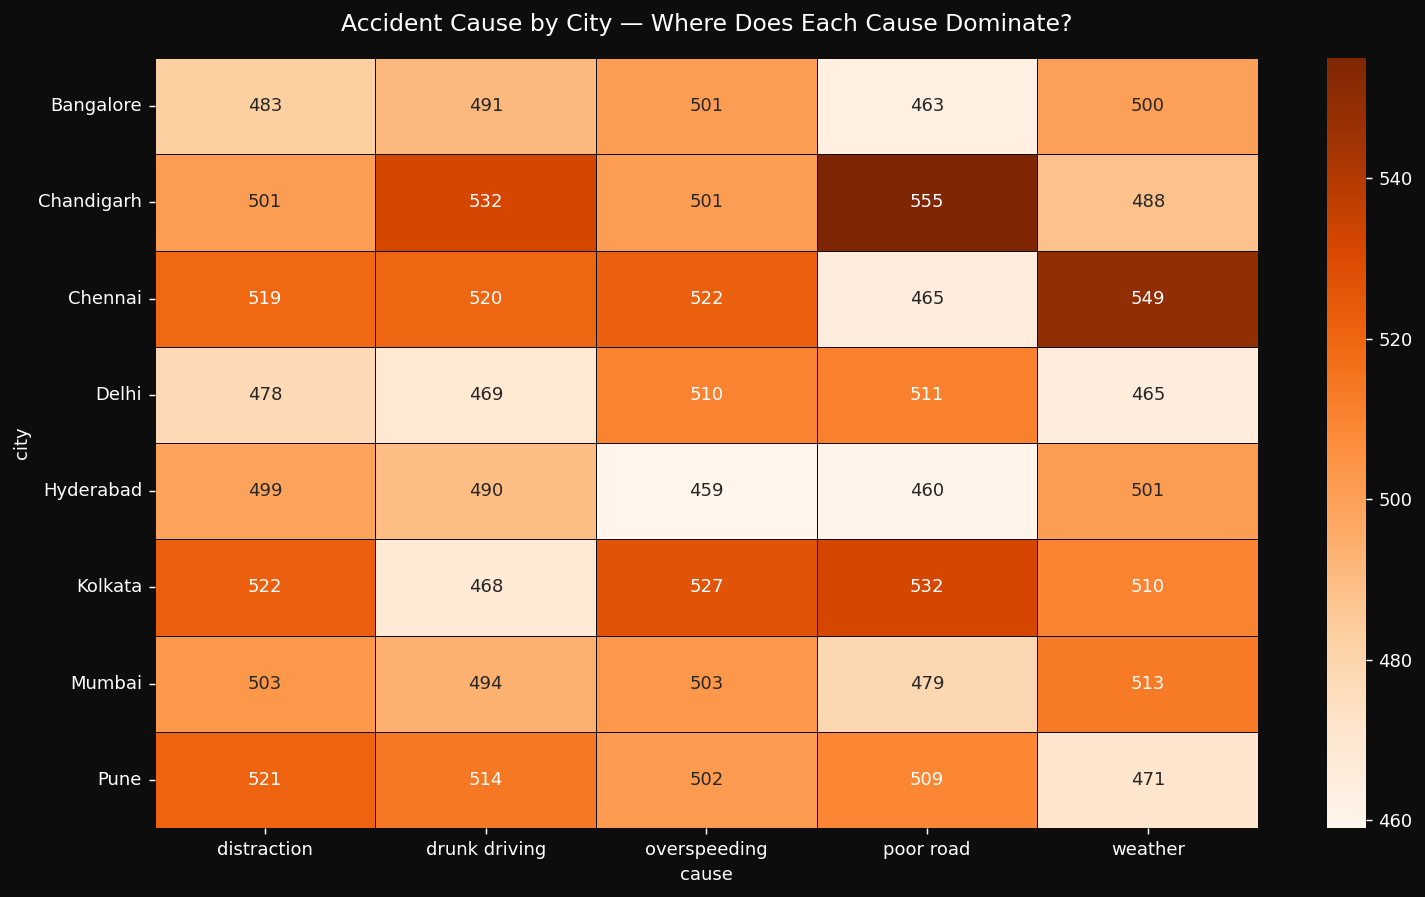

In [18]:
# Cause by city heatmap
cause_city = pd.crosstab(df[city_col], df[cause_col])

fig, ax = plt.subplots(figsize=(12, 7))
ax.set_facecolor('#141414')
sns.heatmap(cause_city, annot=True, fmt='d', cmap='Oranges',
            linewidths=0.5, linecolor='#0d0d0d', ax=ax,
            annot_kws={'size': 10})
ax.set_title('Accident Cause by City — Where Does Each Cause Dominate?',
             fontsize=13, pad=15)
plt.tight_layout()
plt.show()

In [19]:
# Cause by hour — when does each cause peak?
cause_hour = df.groupby([hour_col, cause_col])[acc_id_col].count().reset_index()
cause_hour.columns = [hour_col, cause_col, 'count']

fig = px.line(
    cause_hour, x=hour_col, y='count',
    color=cause_col,
    title='Accident Causes by Hour — When Does Each Cause Peak?',
    labels={hour_col: 'Hour of Day', 'count': 'Number of Accidents'},
    color_discrete_map=CAUSE_COLORS, markers=True
)
fig.update_layout(template='plotly_dark', height=470)
fig.show()

## Section 8 — Weather and Visibility Analysis

Weather is one of the most powerful external factors in road accident severity. Fog reduces reaction time. Rain reduces traction. Low visibility makes it impossible to judge distances accurately.

In [20]:
# Weather and visibility distributions
fig = make_subplots(rows=1, cols=2,
                    specs=[[{'type':'domain'},{'type':'domain'}]],
                    subplot_titles=['Accidents by Weather','Accidents by Visibility'])

weather_counts = df[weather_col].value_counts()
vis_counts     = df[vis_col].value_counts()

fig.add_trace(go.Pie(labels=weather_counts.index, values=weather_counts.values,
                     hole=0.4, marker_colors=['#95a5a6','#2980b9','#7f8c8d']),
              row=1, col=1)
fig.add_trace(go.Pie(labels=vis_counts.index, values=vis_counts.values,
                     hole=0.4, marker_colors=['#e74c3c','#f39c12','#27ae60']),
              row=1, col=2)

fig.update_layout(title='Weather and Visibility at Time of Accident',
                  template='plotly_dark', height=400)
fig.show()

In [21]:
# Fatal rate by weather and visibility
weather_sev = df.groupby(weather_col).agg(
    count=(acc_id_col,   'count'),
    fatal=(severity_col, lambda x: (x=='fatal').sum())
).reset_index()
weather_sev['fatality_rate'] = (weather_sev['fatal']/weather_sev['count']*100).round(2)

vis_sev = df.groupby(vis_col).agg(
    count=(acc_id_col,   'count'),
    fatal=(severity_col, lambda x: (x=='fatal').sum())
).reset_index()
vis_sev['fatality_rate'] = (vis_sev['fatal']/vis_sev['count']*100).round(2)

fig = make_subplots(rows=1, cols=2,
                    subplot_titles=['Fatality Rate by Weather',
                                    'Fatality Rate by Visibility'])

fig.add_trace(go.Bar(
    x=weather_sev[weather_col], y=weather_sev['fatality_rate'],
    marker_color=['#95a5a6','#2980b9','#7f8c8d'],
    text=weather_sev['fatality_rate'].round(1),
    texttemplate='%{text}%', textposition='outside'
), row=1, col=1)

fig.add_trace(go.Bar(
    x=vis_sev[vis_col], y=vis_sev['fatality_rate'],
    marker_color=['#e74c3c','#f39c12','#27ae60'],
    text=vis_sev['fatality_rate'].round(1),
    texttemplate='%{text}%', textposition='outside'
), row=1, col=2)

fig.update_layout(title='Does Bad Weather Actually Make Accidents Deadlier?',
                  template='plotly_dark', height=430, showlegend=False)
fig.show()

In [22]:
# Temperature vs casualties scatter
fig = px.scatter(
    df, x=temp_col, y=casualties_col,
    color=severity_col,
    color_discrete_map=SEVERITY_COLORS,
    trendline='ols', opacity=0.5,
    title='Temperature vs Casualties — Does Heat Affect Accident Severity?',
    labels={temp_col: 'Temperature (°C)', casualties_col: 'Casualties'}
)
fig.update_layout(template='plotly_dark', height=470)
fig.show()

## Section 9 — Road Type and Infrastructure Analysis

Highway accidents are different from urban accidents. Highways involve higher speeds, longer stopping distances, and less access to emergency services. Urban accidents happen in congested traffic with more pedestrians. Rural accidents combine high speed with poor infrastructure.

In [23]:
# Road type analysis
road_summary = df.groupby(road_col).agg(
    count    =(acc_id_col,    'count'),
    fatal    =(severity_col,  lambda x: (x=='fatal').sum()),
    casualties=(casualties_col,'sum'),
    avg_risk =(risk_col,      'mean'),
    avg_vehicles=(vehicles_col,'mean')
).reset_index()
road_summary['fatality_rate'] = (
    road_summary['fatal']/road_summary['count']*100
).round(2)

fig = make_subplots(rows=1, cols=3,
                    subplot_titles=['Accident Count','Fatality Rate (%)','Avg Risk Score'])

for metric, color_list, pos in [
    ('count',        ['#e74c3c','#2980b9','#27ae60'], 1),
    ('fatality_rate',['#e74c3c','#2980b9','#27ae60'], 2),
    ('avg_risk',     ['#e74c3c','#2980b9','#27ae60'], 3)
]:
    fig.add_trace(go.Bar(
        x=road_summary[road_col], y=road_summary[metric],
        marker_color=[ROAD_COLORS.get(r,'#95a5a6') for r in road_summary[road_col]],
        text=road_summary[metric].round(2), textposition='outside',
        showlegend=False
    ), row=1, col=pos)

fig.update_layout(title='Road Type — Where Are Accidents Most Frequent and Deadly?',
                  template='plotly_dark', height=430)
fig.show()

In [24]:
# Lanes vs casualties
lanes_data = df.groupby(lanes_col).agg(
    count    =(acc_id_col,    'count'),
    avg_cas  =(casualties_col,'mean'),
    fatal_rate=(severity_col, lambda x: (x=='fatal').sum()/len(x)*100)
).reset_index()

fig = make_subplots(rows=1, cols=2,
                    subplot_titles=['Accidents by Number of Lanes',
                                    'Avg Casualties by Number of Lanes'])

fig.add_trace(go.Bar(
    x=lanes_data[lanes_col], y=lanes_data['count'],
    marker_color='#2980b9',
    text=lanes_data['count'], textposition='outside'
), row=1, col=1)

fig.add_trace(go.Bar(
    x=lanes_data[lanes_col], y=lanes_data['avg_cas'],
    marker_color='#e74c3c',
    text=lanes_data['avg_cas'].round(2), textposition='outside'
), row=1, col=2)

fig.update_layout(title='Does Lane Count Affect Accident Frequency and Severity?',
                  xaxis_title='Number of Lanes',
                  template='plotly_dark', height=430, showlegend=False)
fig.show()

In [25]:
# Traffic signal presence vs severity
signal_sev = df.groupby([signal_col, severity_col])[acc_id_col]\
               .count().reset_index()
signal_sev.columns = [signal_col, severity_col, 'count']
signal_sev['signal_label'] = signal_sev[signal_col].map(
    {1: 'Signal Present', 0: 'No Signal'}
)

fig = px.bar(signal_sev, x='signal_label', y='count',
             color=severity_col,
             color_discrete_map=SEVERITY_COLORS,
             barmode='group',
             title='Traffic Signal Presence vs Accident Severity',
             text='count')
fig.update_traces(textposition='outside')
fig.update_layout(template='plotly_dark', height=430)
fig.show()

## Section 10 — Festival and Peak Hour Analysis

India's major festivals — Diwali, Holi, Eid, New Year — dramatically change traffic patterns. More vehicles, more drunk driving, more late-night travel. Do festivals actually cause more accidents or more severe ones?

In [26]:
# Festival vs non-festival accidents
fest_summary = df.groupby('festival_label').agg(
    count    =(acc_id_col,    'count'),
    fatal    =(severity_col,  lambda x: (x=='fatal').sum()),
    casualties=(casualties_col,'mean'),
    avg_risk =(risk_col,      'mean')
).reset_index()
fest_summary['fatality_rate'] = (
    fest_summary['fatal']/fest_summary['count']*100
).round(2)

fig = make_subplots(rows=1, cols=2,
                    subplot_titles=['Accidents by Festival',
                                    'Fatality Rate by Festival (%)'])

top_festivals = fest_summary.sort_values('count', ascending=False)

fig.add_trace(go.Bar(
    x=top_festivals['festival_label'], y=top_festivals['count'],
    marker_color=ACC_PALETTE[:len(top_festivals)],
    text=top_festivals['count'], textposition='outside'
), row=1, col=1)

fig.add_trace(go.Bar(
    x=top_festivals['festival_label'], y=top_festivals['fatality_rate'],
    marker_color='#e74c3c',
    text=top_festivals['fatality_rate'].round(1),
    texttemplate='%{text}%', textposition='outside'
), row=1, col=2)

fig.update_layout(title='Do Festivals Make Roads More Dangerous?',
                  template='plotly_dark', height=450, showlegend=False)
fig.show()

In [27]:
# Peak hour vs non-peak analysis
peak_summary = df.groupby(peak_col).agg(
    count    =(acc_id_col,    'count'),
    fatal    =(severity_col,  lambda x: (x=='fatal').sum()),
    casualties=(casualties_col,'mean'),
    avg_risk =(risk_col,      'mean')
).reset_index()
peak_summary['label']        = peak_summary[peak_col].map({1:'Peak Hour',0:'Off Peak'})
peak_summary['fatality_rate']= (peak_summary['fatal']/peak_summary['count']*100).round(2)

fig = make_subplots(rows=1, cols=3,
                    subplot_titles=['Accident Count','Avg Casualties','Fatality Rate (%)'])

for metric, pos in [('count',1),('casualties',2),('fatality_rate',3)]:
    fig.add_trace(go.Bar(
        x=peak_summary['label'], y=peak_summary[metric],
        marker_color=['#e74c3c','#2980b9'],
        text=peak_summary[metric].round(2), textposition='outside',
        showlegend=False
    ), row=1, col=pos)

fig.update_layout(title='Peak Hour vs Off Peak — Are Rush Hour Accidents Deadlier?',
                  template='plotly_dark', height=430)
fig.show()

## Section 11 — Risk Score Analysis

The risk_score column is a pre-computed composite score (0–1) capturing accident risk level. We analyse how it distributes across conditions, cities, and causes — and what the highest-risk accident profiles look like.

In [28]:
# Risk score distribution
fig = make_subplots(rows=1, cols=2,
                    subplot_titles=['Risk Score Distribution',
                                    'Risk Score by Severity'])

fig.add_trace(go.Histogram(x=df[risk_col], nbinsx=40,
                            marker_color='#e74c3c', opacity=0.85), row=1, col=1)
fig.add_vline(x=df[risk_col].mean(), line_dash='dash', line_color='#f1c40f',
              annotation_text=f'Mean: {df[risk_col].mean():.2f}')

for sev, color in SEVERITY_COLORS.items():
    subset = df[df[severity_col]==sev][risk_col]
    fig.add_trace(go.Box(y=subset, name=sev.title(),
                         marker_color=color), row=1, col=2)

fig.update_layout(title='Risk Score — Distribution and Relationship with Severity',
                  template='plotly_dark', height=430, boxmode='group')
fig.show()

In [29]:
# Average risk score by city and cause
risk_city  = df.groupby(city_col)[risk_col].mean().sort_values(ascending=False).reset_index()
risk_cause = df.groupby(cause_col)[risk_col].mean().sort_values(ascending=False).reset_index()

fig = make_subplots(rows=1, cols=2,
                    subplot_titles=['Avg Risk Score by City',
                                    'Avg Risk Score by Cause'])

fig.add_trace(go.Bar(
    x=risk_city[risk_col], y=risk_city[city_col],
    orientation='h', marker_color='#e74c3c',
    text=risk_city[risk_col].round(3), textposition='outside'
), row=1, col=1)

fig.add_trace(go.Bar(
    x=risk_cause[risk_col], y=risk_cause[cause_col],
    orientation='h',
    marker_color=[CAUSE_COLORS.get(c,'#95a5a6') for c in risk_cause[cause_col]],
    text=risk_cause[risk_col].round(3), textposition='outside'
), row=1, col=2)

for i in [1, 2]:
    fig.update_yaxes(categoryorder='total ascending', row=1, col=i)

fig.update_layout(title='Where and Why Are Risk Scores Highest?',
                  template='plotly_dark', height=430, showlegend=False)
fig.show()

## Section 12 — Correlation and Statistical Analysis

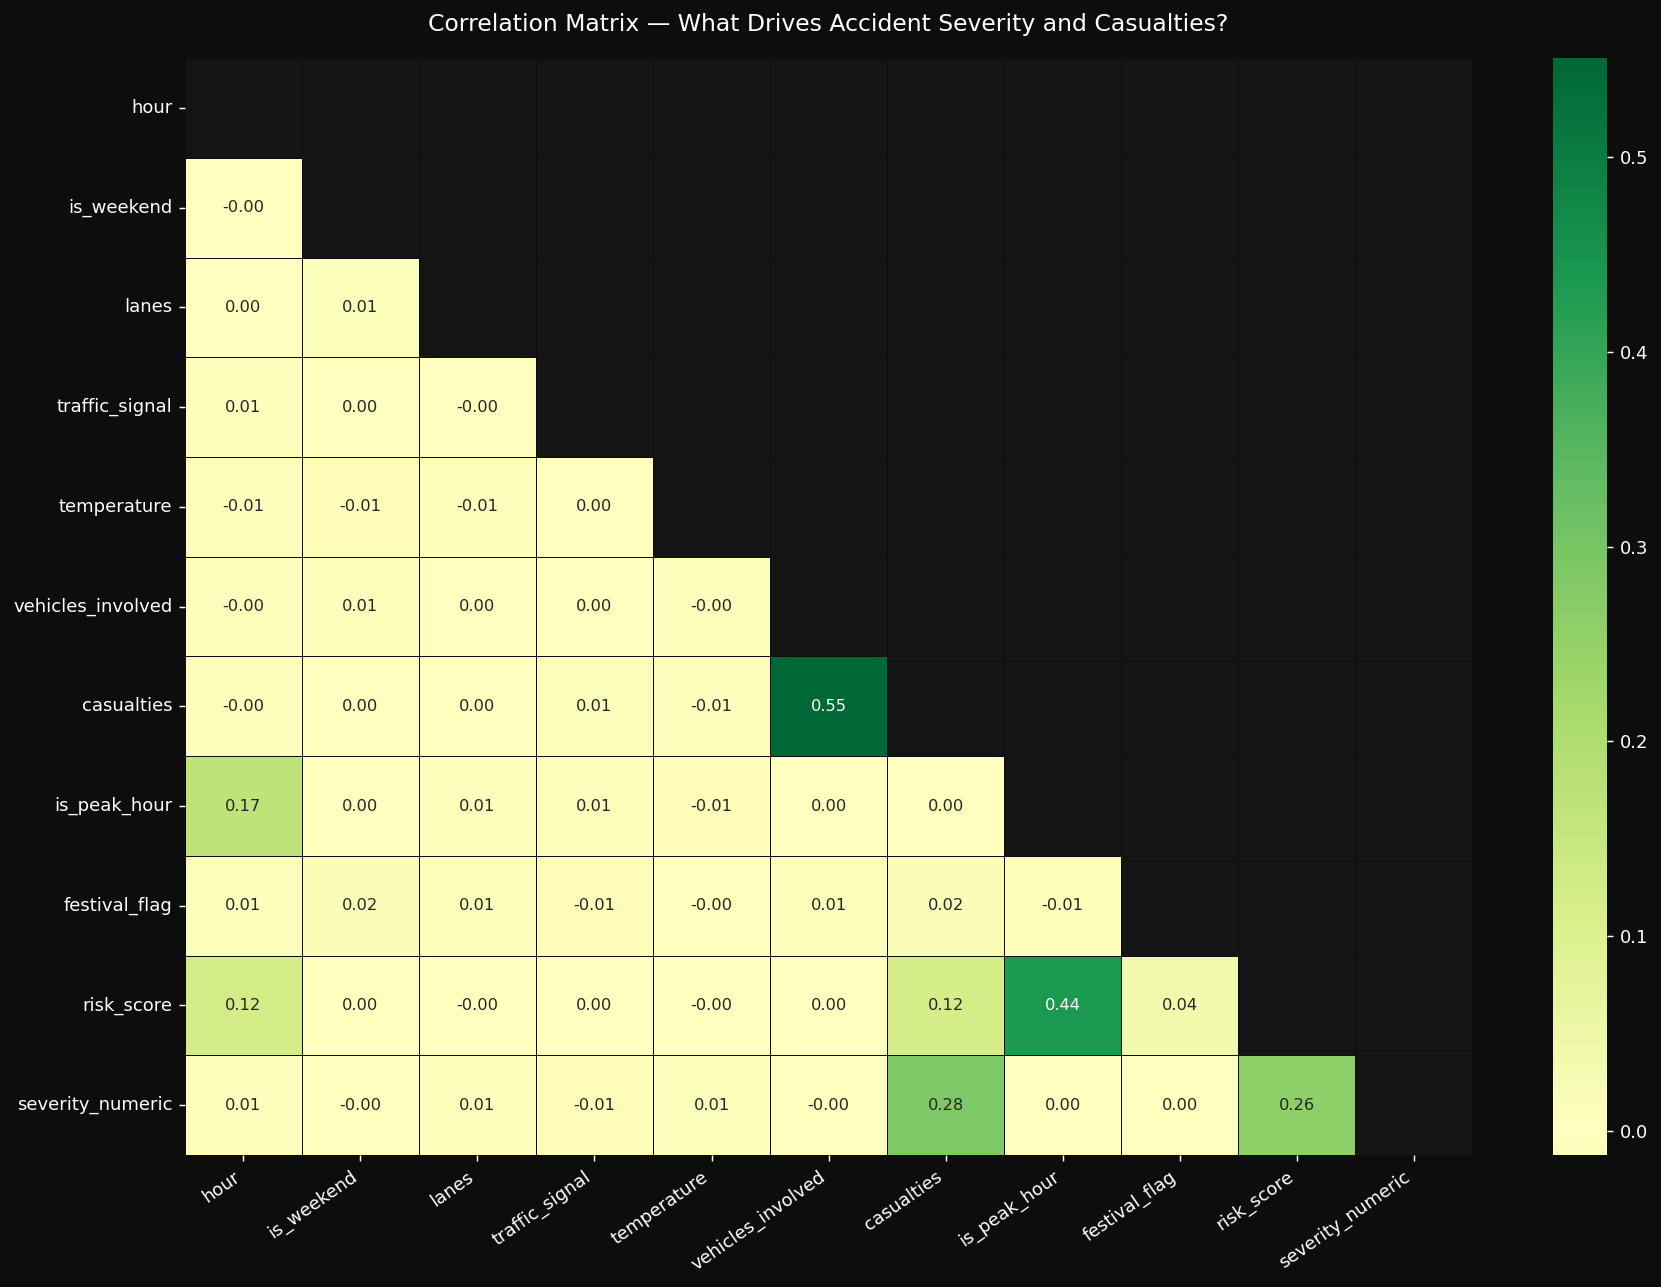

In [30]:
# Numeric correlation heatmap
corr_cols = [hour_col, weekend_col, lanes_col, signal_col,
             temp_col, vehicles_col, casualties_col,
             peak_col, 'festival_flag', risk_col, 'severity_numeric']

corr = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(14, 10))
ax.set_facecolor('#141414')
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, ax=ax,
            linewidths=0.4, linecolor='#0d0d0d',
            annot_kws={'size': 9})
ax.set_title('Correlation Matrix — What Drives Accident Severity and Casualties?',
             fontsize=13, pad=15)
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.show()

In [31]:
# Vehicles involved vs casualties by severity
fig = px.scatter(
    df, x=vehicles_col, y=casualties_col,
    color=severity_col,
    color_discrete_map=SEVERITY_COLORS,
    trendline='ols', opacity=0.5,
    title='Vehicles Involved vs Casualties — More Vehicles = More Casualties?',
    labels={vehicles_col: 'Vehicles Involved',
            casualties_col: 'Casualties'}
)
fig.update_layout(template='plotly_dark', height=480)
fig.show()

In [32]:
# Statistical summary by severity
summary = df.groupby(severity_col).agg(
    count         =(acc_id_col,    'count'),
    avg_casualties=(casualties_col,'mean'),
    avg_vehicles  =(vehicles_col,  'mean'),
    avg_risk      =(risk_col,      'mean'),
    avg_temp      =(temp_col,      'mean'),
    pct_peak      =(peak_col,      'mean'),
    pct_weekend   =(weekend_col,   'mean'),
    pct_festival  =('festival_flag','mean')
).round(3)

display(summary.style
        .background_gradient(cmap='Reds',
                             subset=['avg_casualties','avg_vehicles','avg_risk'])
        .format({'pct_peak': '{:.1%}',
                 'pct_weekend': '{:.1%}',
                 'pct_festival': '{:.1%}'}))

,count,avg_casualties,avg_vehicles,avg_risk,avg_temp,pct_peak,pct_weekend,pct_festival
accident_severity,,,,,,,,
fatal,2987,3.002000,3.002000,0.608000,27.705000,24.8%,28.9%,0.7%
major,5988,1.495000,2.972000,0.407000,27.667000,25.1%,28.1%,0.5%
minor,11025,1.507000,3.000000,0.408000,27.498000,24.5%,28.8%,0.6%


## Section 13 — Key Takeaways

| # | Insight |
|---|---------|
| 1 | Overspeeding is the single largest cause of accidents — and it carries one of the highest fatality rates |
| 2 | Drunk driving causes fewer accidents in absolute terms but has the highest fatality rate of any cause |
| 3 | Fog is deadlier than rain — low visibility conditions create the worst accident outcomes |
| 4 | Highway accidents have a significantly higher fatality rate than urban or rural accidents despite lower frequency |
| 5 | Late night hours (0-4 AM) show the highest fatality rate even though accident frequency is lower |
| 6 | Weekends show higher drunk driving and fatality rates than weekdays |
| 7 | Festival periods show elevated risk scores — Diwali and New Year are the most dangerous |
| 8 | Peak hours have more accidents but off-peak accidents tend to be more severe — fewer cars, higher speeds |
| 9 | Cities with more highway exposure show higher fatality rates regardless of total accident count |
| 10 | Risk score is most strongly correlated with casualties and severity — validating its design as a composite metric |

---

### What Could Be Built on This Dataset

- A fatal accident predictor — classify whether an accident will be fatal from conditions at time of occurrence
- A hotspot mapping tool — geographic clustering of high-risk zones by time of day
- A risk score replication model — reverse-engineer the risk score formula from the features
- A seasonal intervention planner — identify which months and festivals need targeted enforcement
- A cause attribution model — predict accident cause from weather, time, and road conditions

---

If this notebook was useful, please upvote and leave a comment below.